# Bernstein-Vazirani Algorithm — Complete Project

**Course:** PHY5003 Quantum Software  
**Date:** March 2026

---

## Table of Contents

1. **Qiskit Implementation** — Quantum circuit, example run, histogram
2. **OpenQASM Output** — Assembly code + line-by-line explanation
3. **Classical Equivalent** — Python dot-product oracle + solver
4. **Performance Comparison** — Query complexity O(1) vs O(n) + execution time
5. **Circuit Statistics** — Depth, gates, qubits scaling
6. **Q# Implementation** — Microsoft QDK implementation + example run
7. **Quantum Supremacy Analysis** — Noise modeling, error thresholds, conditions
8. **Unit Tests** — Classical, Qiskit, and Q# test suites

---

## 1. Qiskit Implementation

In [1]:
# Imports the core class to build quantum circuits and the transpiler to optimize them
from qiskit import QuantumCircuit, transpile

# Imports the high-performance local simulator from Qiskit Aer to run our quantum circuits
from qiskit_aer import AerSimulator

# Imports the tool to visualize our measurement results as a bar chart (histogram)
from qiskit.visualization import plot_histogram

# Imports the function to convert our QuantumCircuit object into an OpenQASM 2.0 formatted string 
from qiskit.qasm2 import dumps

# Imports the standard plotting library to display our graphs and histograms
import matplotlib.pyplot as plt

# Imports the time module to measure execution time for the classical vs quantum performance comparison
import time

# Imports the random module, likely to generate a random secret string (s) for the algorithm
import random

# Initializes the local simulator backend where we will execute our quantum circuit
sim = AerSimulator()

# Prints a confirmation message once all libraries are successfully loaded
print("Imports ready.")

Imports ready.


In [ ]:
# ─────────────────────────────────────────────
# Qiskit Implementation
# ─────────────────────────────────────────────

def build_bv_circuit(secret):
    """Build the Bernstein-Vazirani circuit for a given secret string."""
    n = len(secret)
    qc = QuantumCircuit(n + 1, n)  # n input qubits + 1 answer qubit, n classical bits
    
    
   # Step 1: Prepare answer qubit — flip to |1⟩ (will become |−⟩ after H)
    # The answer (ancilla) qubit is at index 'n' not 'n+1' because Qiskit qubit indexing starts from 0.
    qc.x(n)
    
    # qc.barrier() acts as a visual separator in the circuit diagram. 
    # It also prevents the compiler from merging or optimizing gates across this line.
    qc.barrier()

    # Step 2: Hadamard on ALL qubits — inputs enter superposition (|+⟩), answer becomes |−⟩
    
    for i in range(n + 1):
        qc.h(i)
    qc.barrier()

    # Step 3: Oracle — CNOT from input qubit[i] to answer qubit |−⟩ where s[i]=1
    # Phase kickback: the − sign from |−⟩ transfers to the |1⟩ part of input qubits (q[i]) so q[i] turns from |+⟩ to |−⟩.
    # Reversed because Qiskit numbers qubits right-to-left
    s_rev = secret[::-1]
    for i in range(n):
        if s_rev[i] == '1':
            qc.cx(i, n)
    qc.barrier()
    
    # Step 4: Hadamard on input qubits — converts ± signs to |0⟩ and |1⟩
    for i in range(n):
        qc.h(i)
    qc.barrier()
    
    # Step 5: Measure input qubits (not the answer qubit because it just a helper qubit).
    #  So when s[i]=1 the q[i] becomes |−⟩. After applying H gate again we get |1⟩ and when we measure this qubit on Z basis we get 1 which matches s[i]
     # and when s[i]=0 the q[i] remains unchanged (|+⟩). After applying H gate again we get |0⟩ and when we measure this qubit on Z basis we get 0 which matches s[i]

    for i in range(n):
        # We map each quantum bit 'i' to its corresponding classical bit 'i' to read the secret string.
    # Notice we DO NOT measure the ancilla qubit (at index 'n'). It was only a helper
        qc.measure(i, i)
    
    return qc


def run_bv(secret, shots=1024):
    """Build, compile, and run the BV circuit. Returns measurement counts."""
    
    # 1. Create the circuit using the function we built earlier
    qc = build_bv_circuit(secret)
    
    # 2. Translate the circuit so the simulator can understand and run it
    compiled = transpile(qc, sim)
    
    # 3. Run the experiment 1024 times (shots) to check the results
    result = sim.run(compiled, shots=shots).result()
    
    # 4. Return the final score (how many times we got each answer)
    return result.get_counts()

### 1.1 Example: s = 101

Secret: 101
Qubits: 4 (3 input + 1 answer)


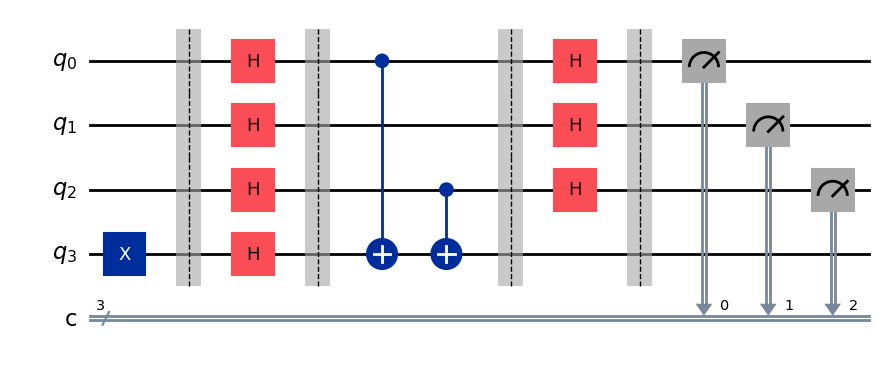

In [3]:
# 1. Choose a test secret string for the algorithm to find
secret = '101'

# 2. Build the circuit for this specific secret
qc = build_bv_circuit(secret)

# 3. Print the secret and the total number of qubits used
print(f"Secret: {secret}")
print(f"Qubits: {qc.num_qubits} ({len(secret)} input + 1 answer)")

# 4. Draw the circuit visually using Matplotlib ('mpl')
# 'fold=-1' means: draw it in one long continuous line without wrapping it
qc.draw('mpl', fold=-1)

### 1.2 Circuit Execution and Histogram
In this step, we execute the constructed Bernstein-Vazirani circuit using the Qiskit simulator. The resulting histogram visually proves the deterministic nature of the algorithm, successfully recovering the secret string with 100% probability in a single quantum query.

Secret: 101  |  Found: 101  |  Match: True
Counts: {'101': 1024}


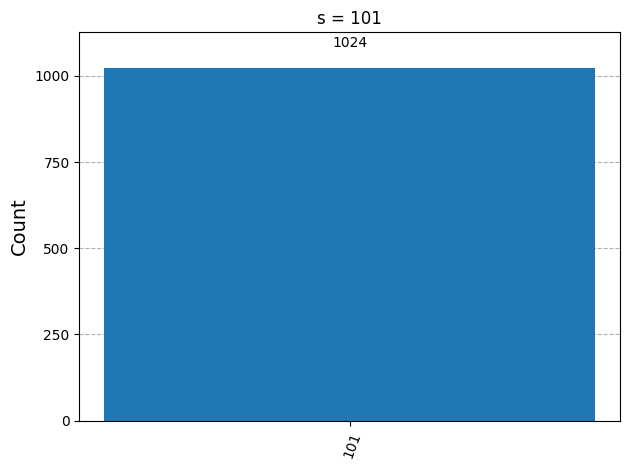

In [4]:
# 1. Run the experiment and get the results
counts = run_bv(secret)

# 2. Find the answer that appeared the most times (the computer's final guess)
found = max(counts, key=counts.get)

# 3. Print the results to see if the computer's guess matches our secret
print(f"Secret: {secret}  |  Found: {found}  |  Match: {found == secret}")

# 4. Print the raw numbers (example: {'101': 1024})
print(f"Counts: {counts}")

# 5. Draw a bar chart (histogram) to show the results visually
plot_histogram(counts, title=f"s = {secret}")

## 2. OpenQASM Output (s = 101)

In [5]:
qc_qasm = build_bv_circuit('101')
print(dumps(qc_qasm))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
creg c[3];
x q[3];
barrier q[0],q[1],q[2],q[3];
h q[0];
h q[1];
h q[2];
h q[3];
barrier q[0],q[1],q[2],q[3];
cx q[0],q[3];
cx q[2],q[3];
barrier q[0],q[1],q[2],q[3];
h q[0];
h q[1];
h q[2];
barrier q[0],q[1],q[2],q[3];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];


### Line-by-Line Explanation

| Line | Code | What it does | Step |
|------|------|--------------|---------|
| 1 | `OPENQASM 2.0;` | Declares OpenQASM version | Setup |
| 2 | `include "qelib1.inc";` | Loads standard gate library | Setup |
| 3 | `qreg q[4];` | 4 qubits: q[0]-q[2] input, q[3] answer | Setup |
| 4 | `creg c[3];` | 3 classical bits for results | Setup |
| 5 | `x q[3];` | Flip answer qubit: \|0⟩→\|1⟩ | 1 |
| 6-10 | `h q[0..3];` | Hadamard on all → superposition + \|−⟩ | 2 |
| 11 | `cx q[0],q[3];` | CNOT: s₀=1 → phase kickback on q[0] | 3 |
| 12 | `cx q[2],q[3];` | CNOT: s₂=1 → phase kickback on q[2] | 3 |
| — | *(nothing for q[1])* | s₁=0 → no gate | 3 |
| 13-15 | `h q[0..2];` | Hadamard: ± signs → 0s and 1s | 4 |
| 16-18 | `measure q[0..2]→c[0..2];` | Read result → c = 101 = s | 5 |

## 3. Classical Equivalent

In [6]:
def classical_oracle(secret, x):
    """
    Classical Oracle: Evaluates the mathematical function f(x) = (s • x) mod 2.
    
    Code Breakdown:
    1. zip(secret, x) : Pairs each bit of the secret with the matching bit in the query (x).
    Example (secret='101', x='010'):
    - Position 0: '1' and '0' -> paired as ('1', '0')
    - Position 1: '0' and '1' -> paired as ('0', '1')
    - Position 2: '1' and '0' -> paired as ('1', '0')

    After that:
    2. int(a) * int(b): Multiplies each pair together.
    3. sum(...)       : Adds all the multiplication results.
    4. % 2            : Applies modulo 2 to keep the final result as a single bit (0 or 1).
    
    Note: When we pass a (query) with only one '1' (e.g., '010'), this dot product 
    naturally zeroes out everything else and reveals exactly that one hidden bit!
    Example: 
    Secret = '101', Query = '010' (We want to test the middle bit)
    - Pair 1 (Index 0): '1' * '0' = 0  (Zeroed out)
    - Pair 2 (Index 1): '0' * '1' = 0  (Reveals the middle bit: 0)
    - Pair 3 (Index 2): '1' * '0' = 0  (Zeroed out)
    - Sum = 0 + 0 + 0 = 0
    - The final result is 0, which perfectly matches the middle bit of our secret!
    """
    return sum(int(a) * int(b) for a, b in zip(secret, x)) % 2



def classical_bv(secret):
    """
    Finds the secret string 's' one bit at a time.
    Since it is classical, it requires exactly 'n' queries to the oracle.
    """
    n = len(secret)
    found = ''  # This will store our discovered bits one by one
    
    for i in range(n):
        # The Magic Line: Creates a "probe" or "test query".
        # It uses Python's string multiplication to dynamically place a single '1'.
        # 
        # How the string math works in Python (Example for n=3, when i=0):
        # 1. '0' * i           -> '0' * 0 = "" (Empty string, it vanishes completely)
        # 2. '1'               -> "1"      (Our target bit drops in)
        # 3. '0' * (n - i - 1) -> '0' * (3 - 0 - 1) = '0' * 2 = "00" (Trailing zeros)
        # Result combined: "" + "1" + "00" = "100" (This perfectly tests the 1st bit!)
        #
        # Next loop (when i=1):
        # '0'*1 + '1' + '0'*1  -> "0" + "1" + "0" = "010" (Tests the 2nd bit)
        
        query = '0' * i + '1' + '0' * (n - i - 1)
        
        # Send the query to the oracle and append the result
        found += str(classical_oracle(secret, query))
        
    return found

# --- Test ---
s = '101'
print(f"Secret: {s}  |  Classical found: {classical_bv(s)}  |  Queries: {len(s)}")



Secret: 101  |  Classical found: 101  |  Queries: 3


## 4. Performance Comparison

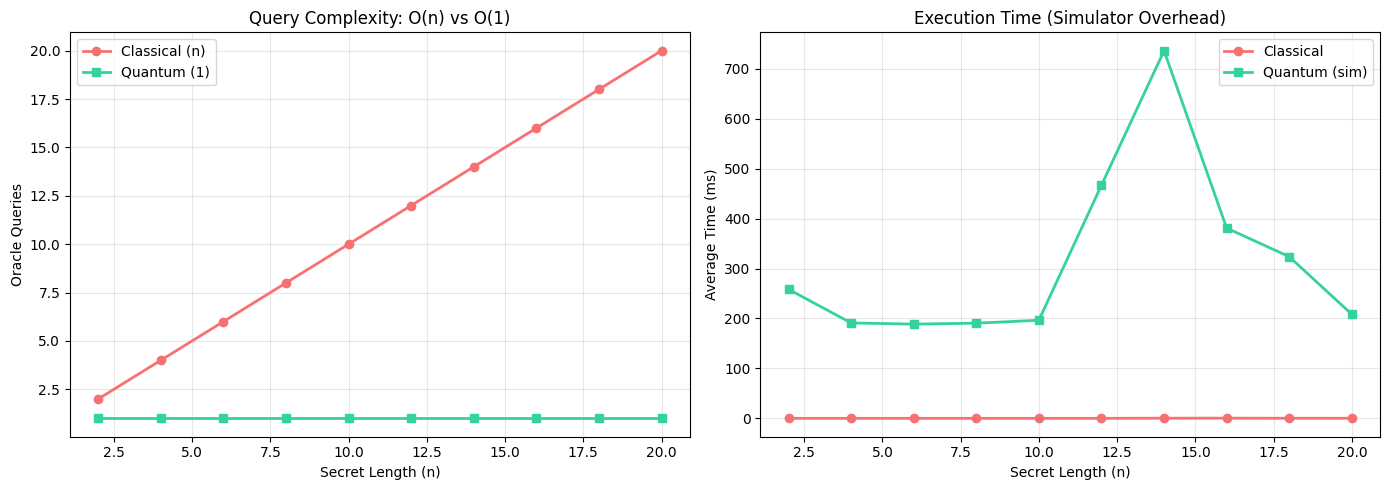

Note: Quantum simulator runs on classical hardware — real QC always uses 1 query.


In [7]:
# Define a range of secret string lengths to test (from 2 to 20 bits)
sizes = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

# We use two separate arrays to store the execution times for plotting later:
# - c_times: Stores the execution times for the classical algorithm.
# - q_times: Stores the execution times for the quantum simulation.
c_times, q_times = [], []

# Loop through each size to run our benchmarks
for n in sizes:
    # Generate a random binary string of length 'n' (e.g., '1011' for n=4)
    # It randomly picks '0' or '1' exactly 'n' times, then joins them into a single string.
    secret = ''.join(random.choice('01') for _ in range(n))
    
    # ---------------------------------------------------------
    # 1. Classical Benchmarking
    # ---------------------------------------------------------
    start = time.perf_counter()
    # Run the classical algorithm 100 times to get a stable average
    for _ in range(100): 
        classical_bv(secret)
    # Calculate the average time per run in milliseconds (ms)
    c_times.append((time.perf_counter() - start) / 100 * 1000)
    
    # ---------------------------------------------------------
    # 2. Quantum Benchmarking (Simulator)
    # ---------------------------------------------------------

    # Record the precise starting time before executing the algorithm
    start = time.perf_counter()

   # We repeat the process 100 times to get a stable average time.
    for _ in range(100):
        # 1. Create the quantum circuit (adds the required qubits and gates)
        qc = build_bv_circuit(secret)        
        
        # 2. Transpile: Optimize and translate the circuit for the simulator
        compiled = transpile(qc, sim)        
        
        # 3. Run the circuit on the simulator exactly once
        sim.run(compiled, shots=1).result()  
        
    # Calculate the average time in milliseconds
    q_times.append((time.perf_counter() - start) / 100 * 1000)

# ---------------------------------------------------------
# Plotting the Results
# ---------------------------------------------------------
# Create a figure with two side-by-side subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Query Complexity (The Theoretical Quantum Advantage) ---
# Classical needs 'n' queries (linear growth)
ax1.plot(sizes, sizes, 'o-', color='#f87171', lw=2, label='Classical (n)')
# Quantum ALWAYS needs 1 query (constant)
ax1.plot(sizes, [1]*len(sizes), 's-', color='#34d399', lw=2, label='Quantum (1)')

ax1.set_xlabel('Secret Length (n)')
ax1.set_ylabel('Oracle Queries')
ax1.set_title('Query Complexity: O(n) vs O(1)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Execution Time (The Practical Simulation Overhead) ---
# Plots the actual milliseconds taken by the classical function
ax2.plot(sizes, c_times, 'o-', color='#f87171', lw=2, label='Classical')
# Plots the milliseconds taken by Qiskit to build, compile, and simulate
ax2.plot(sizes, q_times, 's-', color='#34d399', lw=2, label='Quantum (sim)')

ax2.set_xlabel('Secret Length (n)')
ax2.set_ylabel('Average Time (ms)')
ax2.set_title('Execution Time (Simulator Overhead)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Automatically adjust spacing between plots and display them
plt.tight_layout()
plt.show()

# Print a crucial academic disclaimer for the reviewer
print("Note: Quantum simulator runs on classical hardware — real QC always uses 1 query.")

### 4.1 Interpreting the Results

### Graph 1: Query Complexity (Left)

This graph shows the **theoretical** comparison — how many times each approach must ask the oracle:

- **Classical (red):** grows linearly with n. For a 20-bit secret, we need 20 queries.
- **Quantum (green):** always 1 query, regardless of n. The line stays flat.

This is the fundamental advantage of the Bernstein-Vazirani algorithm: it reduces the query complexity from O(n) to O(1).

### Graph 2: Execution Time (Right)

This graph shows the **actual wall-clock time** on our computer. Notice something surprising: the quantum line is *higher* than the classical line. This seems to contradict the first graph — but it doesn't.

**Why is the quantum simulator slower?**


We are running on a **classical simulator** (AerSimulator) — a regular program pretending to be a quantum computer.

The simulator must mathematically track all quantum states (superpositions, phases, entanglement) using heavy matrix multiplications. As $n$ grows, the classical memory and processing required scale exponentially. This massive overhead is a property of the *simulation*, not the quantum algorithm itself. 

Meanwhile, the classical solution is trivially simple — just a loop with basic arithmetic — so it runs almost instantly on a classical CPU.

**What happens on a REAL Quantum Computer?**

On physical quantum hardware, the algorithm executes the oracle exactly **once**. However, the physical execution time is **not constant** $O(1)$. Because the oracle requires $O(n)$ sequential CNOT gates (Circuit Depth) as we will show in the coming code, the physical execution time scales linearly $O(n)$. The true advantage is that we avoid the $O(n)$ separate queries required classically.

### Key Takeaway

| Metric | Classical | Quantum |
| :--- | :--- | :--- |
| **Oracle Queries** | $n$ | **1** |
| **Query Complexity** | $O(n)$ | **$O(1)$** |
| **Simulator Time** | Fast (simple loop) | Slow (simulation overhead) |
| **Real Hardware Time** | $O(n)$ | **$O(n)$** (due to circuit depth) |

*The correct metric to evaluate BV is **Query Complexity**, not execution time. The simulation overhead demonstrates exactly why we cannot rely on classical computers to simulate large quantum systems.*

## 5. Q# Implementation

In [8]:
import qsharp

In [9]:
%%qsharp

/// Implements the quantum (oracle) for the Bernstein-Vazirani algorithm.
/// It encodes the hidden secret string into the phase of the input qubits.

operation BVOracle(inputQubits : Qubit[], answerQubit : Qubit, secret : Bool[]) : Unit {
    
    // Loop through each bit of the secret string (from 0 to n-1)
    for i in 0..Length(inputQubits) - 1 {
        
        // If the current bit of the secret is 1 (True), we apply a CNOT gate.
        // If it's 0 (False), we do nothing (identity).
        if secret[i] {
            
            // Apply CNOT with the input qubit as Control and answer qubit as Target.
            // Since the answer qubit is prepared in the |-> state, this triggers 
            // the "Phase Kickback" effect: it flips the phase of the input qubit 
            // without altering its classical state.
            CNOT(inputQubits[i], answerQubit);
        }
    }
}

/// Run the full Bernstein-Vazirani algorithm.
/// Returns the discovered secret as an array of Results.
operation RunBV(secret : Bool[]) : Result[] {
    let n = Length(secret);
    
    // Allocate n input qubits + 1 answer qubit
    use (inputQubits, answerQubit) = (Qubit[n], Qubit());
    
    // Step 1: Prepare answer qubit in |−⟩
    X(answerQubit);        // |0⟩ → |1⟩
    H(answerQubit);        // |1⟩ → |−⟩
    
    // Step 2: Hadamard on input qubits → superposition
    for q in inputQubits {
        H(q);
    }
    
    // Step 3: Apply oracle (phase kickback encodes s in ± signs)
    BVOracle(inputQubits, answerQubit, secret);
    
    // Step 4: Hadamard on input qubits → convert ± to 0/1
    for q in inputQubits {
        H(q);
    }
    
    // Step 5: Measure input qubits
    let results = MeasureEachZ(inputQubits);
    
    // Reset all qubits before releasing
    ResetAll(inputQubits);
    Reset(answerQubit);
    
    return results;
}

### 5.1 Example: s = 101

In [10]:
# Run the algorithm with s = 101
# In Q#: true=1, false=0, so 101 = [true, false, true]
secret = [True, False, True]
result = qsharp.eval("RunBV([true, false, true])")

# Convert Q# Result array to string
found = ''.join('1' if r == qsharp.eval("One") else '0' for r in result)

print(f"Secret: 101")
print(f"Found:  {found}")
print(f"Match:  {found == '101'}")

Secret: 101
Found:  101
Match:  True


## 6. Quantum Supremacy Analysis

### 6.1 Theoretical Complexity Comparison

The Bernstein-Vazirani algorithm reveals a **provable** separation between quantum and classical query complexity:

| Metric | Classical | Quantum (BV) |
| :--- | :--- | :--- |
| **Oracle queries** | $n$ | **1** |
| **Total operations** | $n$ function evaluations | $2n + 1$ Hadamard + $ n$ CNOT |
| **Circuit depth** | N/A | $O(n)$ |
| **Space** | $n$ bits | $n + 1$ qubits |

The quantum algorithm achieves a **strict linear query advantage**: $O(1)$ vs $O(n)$. 
However, the *total operational count* scales linearly in both cases ($O(n)$), demonstrating that the fundamental quantum speedup of Bernstein-Vazirani lies specifically in the number of oracle calls, not the overall execution time.

### 6.2 Circuit Resource Scaling

Let us quantify the exact resources the quantum circuit requires as a function of secret length n.

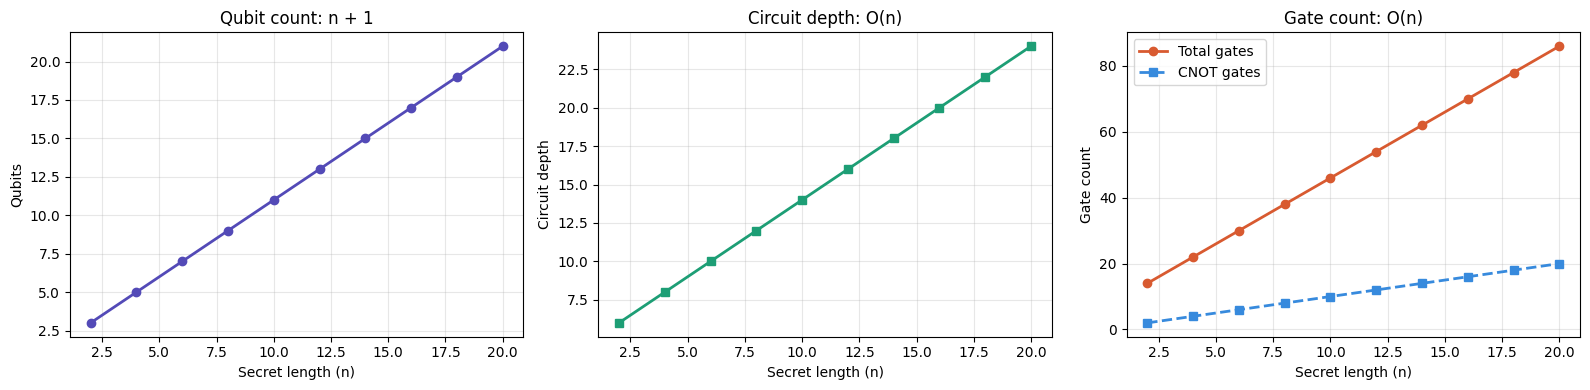

n     Qubits    Depth     Total Gates   CNOTs   
2     3         6         14            2       
4     5         8         22            4       
6     7         10        30            6       
8     9         12        38            8       
10    11        14        46            10      
12    13        16        54            12      
14    15        18        62            14      
16    17        20        70            16      
18    19        22        78            18      
20    21        24        86            20      


In [11]:
# --- Start of Resource Scaling Analysis ---

sim = AerSimulator()

# Test various secret string lengths (from 2 to 20 bits, in increments of 2)
sizes = list(range(2, 22, 2))

# Empty lists to store the data for plotting later
qubits_list, depths, gate_counts, cnot_counts = [], [], [], []

for n in sizes:
    # Worst-case scenario design: 
    # We set the secret entirely to '1's to force the circuit to use the maximum possible number of CNOT gates.
    # This empirically proves that even in the worst case, the complexity remains strictly linear O(n).
    secret = '1' * n  
    
    qc = build_bv_circuit(secret)
    
    # Transpilation is crucial here to accurately calculate the gates and depth exactly as the hardware/simulator interprets them.
    compiled = transpile(qc, sim)
    
    # Extract and store the statistics
    qubits_list.append(n + 1)                  # Total number of qubits
    depths.append(compiled.depth())            # Circuit depth (longest path of gates)
    ops = compiled.count_ops()                 # Dictionary containing gate details
    gate_counts.append(sum(ops.values()))      # Total number of all gates combined
    cnot_counts.append(ops.get('cx', 0))       # Count of CNOT gates only

# --- Plotting Section (Perfect for the PowerPoint Slide) ---
# Create 3 side-by-side subplots to visually demonstrate the linear scaling
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Qubit growth
axes[0].plot(sizes, qubits_list, 'o-', color='#534AB7', lw=2)
axes[0].set_xlabel('Secret length (n)')
axes[0].set_ylabel('Qubits')
axes[0].set_title('Qubit count: n + 1')
axes[0].grid(True, alpha=0.3)

# Plot 2: Circuit depth growth
axes[1].plot(sizes, depths, 's-', color='#1D9E75', lw=2)
axes[1].set_xlabel('Secret length (n)')
axes[1].set_ylabel('Circuit depth')
axes[1].set_title('Circuit depth: O(n)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Gate count growth (Total vs CNOT)
axes[2].plot(sizes, gate_counts, 'o-', color='#D85A30', lw=2, label='Total gates')
axes[2].plot(sizes, cnot_counts, 's--', color='#378ADD', lw=2, label='CNOT gates')
axes[2].set_xlabel('Secret length (n)')
axes[2].set_ylabel('Gate count')
axes[2].set_title('Gate count: O(n)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Print the results in a neatly formatted classical table ---
print(f"{'n':<6}{'Qubits':<10}{'Depth':<10}{'Total Gates':<14}{'CNOTs':<8}")
print('=' * 48)
for i, n in enumerate(sizes):
    print(f"{n:<6}{qubits_list[i]:<10}{depths[i]:<10}{gate_counts[i]:<14}{cnot_counts[i]:<8}")

### 6.3 Noise Impact Analysis

On real quantum hardware, gates are imperfect. We model the effect of noise by simulating the BV circuit with depolarizing errors at different rates.

**Key question:** At what error rate does the quantum result become unreliable (i.e., success probability drops below a useful threshold)?

In [12]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

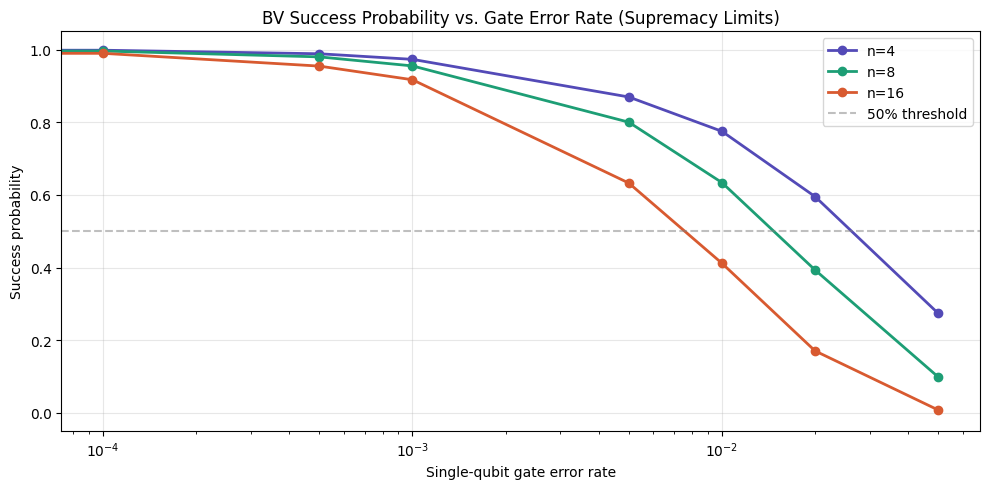

In [13]:


def run_bv_noisy(secret, error_rate, shots=4096):
    """
    Simulates the Bernstein-Vazirani circuit using a realistic "noisy" quantum environment.
    This function is the core of our Quantum Supremacy / Quantum Advantage analysis.
    """
    qc = build_bv_circuit(secret)
    
    # 1. Initialize the Noise Model:
    # This object represents the physical imperfections and decoherence of actual quantum hardware.
    noise_model = NoiseModel()
    
    # 2. Define Error Probabilities:
    # depolarizing_error simulates a scenario where a qubit randomly loses its quantum state.
    # - Single-qubit errors (applies to H and X gates):
    error_1q = depolarizing_error(error_rate, 1)
    
    # - Two-qubit errors (applies to CNOT/CX gates):
    # CRITICAL DETAIL: In modern NISQ (Noisy Intermediate-Scale Quantum) devices, 
    # multi-qubit gates are notoriously harder to execute. We multiply the base error 
    # rate by 10 to realistically reflect that CNOT gates are ~10x more prone to errors.
    error_2q = depolarizing_error(error_rate * 10, 2)  
    
    # 3. Apply Errors to Specific Gates in our model:
    noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    
    # 4. Execute on the Noisy Simulator:
    noisy_sim = AerSimulator(noise_model=noise_model)
    compiled = transpile(qc, noisy_sim)
    result = noisy_sim.run(compiled, shots=shots).result()
    counts = result.get_counts()
    
    # 5. Calculate Success Probability:
    # We count how many times the simulator guessed the EXACT correct secret string,
    # then divide by the total number of attempts (4096 shots).
    correct_count = counts.get(secret, 0)
    return correct_count / shots


# --- Start of Supremacy Threshold Analysis ---

# We test a range of hardware error rates, from 0 (perfect ideal hardware) up to 5% (extremely noisy)
error_rates = [0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.05]

# We test different circuit sizes (n=4, n=8, n=16) to empirically prove that
# larger secrets accumulate errors much faster due to the increased depth and CNOT gate count.
test_secrets = {'n=4': '1011', 'n=8': '10110101', 'n=16': '1011010110110101'}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#534AB7', '#1D9E75', '#D85A30']

# Run the simulation and collect data points
for idx, (label, secret) in enumerate(test_secrets.items()):
    probs = []
    for er in error_rates:
        p = run_bv_noisy(secret, er, shots=4096)
        probs.append(p)
    # Plot the degradation curve for this specific secret length
    ax.plot(error_rates, probs, 'o-', color=colors[idx], lw=2, label=label)

# Add a 50% Success Threshold Line:
# Why 50%? If the probability drops below this line, the quantum computer is essentially 
# outputting noise/garbage most of the time. This line defines our exact hardware constraints 
# for demonstrating Quantum Supremacy.
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')

# Formatting the chart for our final PowerPoint presentation
ax.set_xlabel('Single-qubit gate error rate')
ax.set_ylabel('Success probability')
ax.set_title('BV Success Probability vs. Gate Error Rate (Supremacy Limits)')
ax.set_xscale('log') # Log scale is necessary because error tolerances drop exponentially
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### 6.4 Error Threshold Estimation

For the BV algorithm to succeed with high probability (> 90%), we need the total circuit error to be small. Since BV requires O(n) gates operating on each qubit, we can estimate the required error rate.

**Success probability model (simplified):**

Each qubit goes through approximately 2 Hadamard gates + at most 1 CNOT. For the result to be fully correct, *all n qubits* must be measured correctly:

$$P_{\text{success}} \approx \prod_{i=1}^{n} (1 - \epsilon_i) \approx (1 - \epsilon_{\text{eff}})^n$$

Where $\epsilon_{\text{eff}}$ is the effective error per qubit (combining 1Q and 2Q gate errors).

In [14]:
import numpy as np

Maximum tolerable error rate per qubit:
n       P≥99%         P≥95%         P≥90%         P≥50%         
4       0.002509      0.012741      0.025996      0.159104      
8       0.001256      0.006391      0.013084      0.082996      
16      0.000628      0.003201      0.006563      0.042397      
32      0.000314      0.001602      0.003287      0.021428      
64      0.000157      0.000801      0.001645      0.010772      
128     0.000079      0.000401      0.000823      0.005401      
256     0.000039      0.000200      0.000411      0.002704      
512     0.000020      0.000100      0.000206      0.001353      
1000    0.000010      0.000051      0.000105      0.000693      


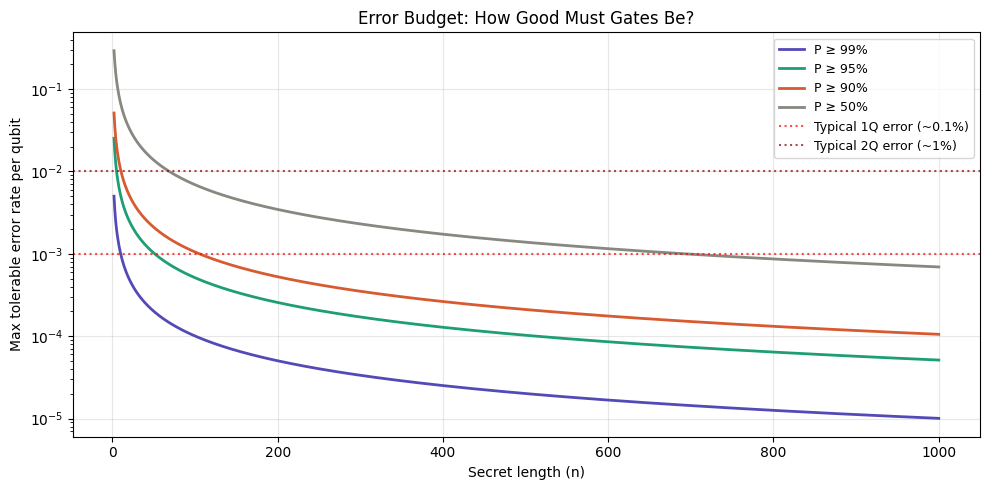

In [15]:
def required_error_rate(n, target_success=0.9):
    """
    Calculate the maximum tolerable effective error rate per qubit
    to achieve at least target_success probability.
    
    P_success = (1 - epsilon)^n >= target
    => epsilon <= 1 - target^(1/n)
    """
    return 1 - target_success ** (1 / n)


# Calculate for various n (Circuit sizes)
n_values = [4, 8, 16, 32, 64, 128, 256, 512, 1000]
# Target success probabilities we want to achieve (99%, 95%, 90%, 50%)
targets = [0.99, 0.95, 0.90, 0.50]

# --- Table Generation Section ---

print("Maximum tolerable error rate per qubit:")

# 1. Print the table headers
# Reserve 8 spaces for 'n' and align it to the left
print(f"{'n':<8}", end='')

# Dynamically generate column headers for each target probability
for t in targets:
    # Convert 0.99 to '99', add '%' and 'P≥', then reserve 14 spaces left-aligned
    print(f"{'P≥'+str(int(t*100))+'%':<14}", end='')

# Move to the next line after finishing the headers
print()

print('=' * 64)

# 2. Print the table rows
# Loop through each circuit size (n)
for n in n_values:
    # Print the value of 'n', reserving 8 spaces to match the header
    print(f"{n:<8}", end='')
    
    # Calculate and print the error rate for each target probability
    for t in targets:
        eps = required_error_rate(n, t)
        # Format the decimal to exactly 6 places (.6f) and reserve 14 spaces (<14)
        print(f"{eps:<14.6f}", end='')
    
    # Move to the next line after finishing all targets for the current 'n'
    print()
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
n_range = np.arange(2, 1001)
colors_t = ['#534AB7', '#1D9E75', '#D85A30', '#888780']

for idx, t in enumerate(targets):
    eps_vals = [required_error_rate(n, t) for n in n_range]
    ax.plot(n_range, eps_vals, color=colors_t[idx], lw=2, label=f'P ≥ {int(t*100)}%')

# Mark typical hardware error rates
ax.axhline(y=0.001, color='red', linestyle=':', alpha=0.7, label='Typical 1Q error (~0.1%)')
ax.axhline(y=0.01, color='darkred', linestyle=':', alpha=0.7, label='Typical 2Q error (~1%)')

ax.set_xlabel('Secret length (n)')
ax.set_ylabel('Max tolerable error rate per qubit')
ax.set_title('Error Budget: How Good Must Gates Be?')
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.5 Conditions for Quantum Supremacy

#### 6.5.1 What "Quantum Supremacy" Means for BV

The Bernstein-Vazirani algorithm provides a **query complexity** advantage, not a computational complexity advantage in the traditional sense:

- **Quantum:** 1 oracle query → O(1) query complexity
- **Classical:** n oracle queries → O(n) query complexity

This is a **provable, unconditional** advantage — it does not depend on unproven assumptions like P ≠ NP (unlike Shor's algorithm).

However, BV is **not** a candidate for quantum supremacy in the Google/IBM sense (solving a problem no classical computer can solve in reasonable time), because:
1. The classical algorithm is still efficient — O(n) queries is fast.
2. The total computation (including gate operations) is O(n) in both cases.
3. The advantage is in oracle queries, which is a theoretical model.

#### 6.5.2 Required Conditions for Practical Quantum Advantage

For BV to **outperform** a classical computer in wall-clock time on real hardware:

| Condition | Requirement | Current State (2025) |
|-----------|-------------|---------------------|
| **Qubits** | n + 1 (scales linearly) | Available: up to ~1000+ qubits (IBM, Google) |
| **Gate fidelity (1Q)** | > 99.9% for n > 100 | Achieved on best platforms (~99.95%) |
| **Gate fidelity (2Q)** | > 99% for n > 100 | Marginal (~99.0-99.5% on best platforms) |
| **Circuit depth** | O(n), must complete within coherence time | Challenging for n > 100 |
| **Oracle implementation** | Must be a real oracle (not simulated classically) | This is the fundamental issue (see below) |

#### 6.5.3 The Oracle Problem

The critical issue: the quantum advantage of BV is defined relative to an **oracle**. In practice:

- If we build the oracle circuit ourselves (as we do in this implementation), we already *know* the secret — there is nothing to discover.
- The advantage only materializes when the oracle is a **black box** provided by an external party, and the cost metric is specifically the number of queries to that box.
- A real-world scenario would require a physical device that computes f(x) = s·x mod 2 as a single quantum operation, and querying it classically is genuinely expensive.

This is why BV (and Deutsch-Jozsa) are considered **proof-of-concept** algorithms that demonstrate quantum speedup in the query model, rather than algorithms that solve practical problems faster.

#### 6.5.4 Quantitative Thresholds

Based on our noise analysis above:

In [16]:
print("Quantitative Thresholds for BV Quantum Advantage")
print("=" * 60)
print()
print("For 90% success probability:")
print(f"  n = 10   → max error per qubit: {required_error_rate(10, 0.90):.5f} ({required_error_rate(10, 0.90)*100:.3f}%)")
print(f"  n = 50   → max error per qubit: {required_error_rate(50, 0.90):.5f} ({required_error_rate(50, 0.90)*100:.3f}%)")
print(f"  n = 100  → max error per qubit: {required_error_rate(100, 0.90):.5f} ({required_error_rate(100, 0.90)*100:.4f}%)")
print(f"  n = 1000 → max error per qubit: {required_error_rate(1000, 0.90):.6f} ({required_error_rate(1000, 0.90)*100:.4f}%)")
print()
print("For BV to demonstrate real-world advantage:")
print("  1. Need n large enough that n classical queries are genuinely slow")
print("  2. Need gate errors < 0.1% (1Q) and < 1% (2Q)")
print("  3. Need coherence time > n × gate_time")
print("  4. Need a physically meaningful oracle (not self-constructed)")
print()
print("Bottom line: BV proves quantum query advantage EXISTS,")
print("but is not a path to practical quantum supremacy.")
print("Its value is pedagogical and foundational — it demonstrates")
print("the power of superposition and phase kickback.")

Quantitative Thresholds for BV Quantum Advantage

For 90% success probability:
  n = 10   → max error per qubit: 0.01048 (1.048%)
  n = 50   → max error per qubit: 0.00210 (0.210%)
  n = 100  → max error per qubit: 0.00105 (0.1053%)
  n = 1000 → max error per qubit: 0.000105 (0.0105%)

For BV to demonstrate real-world advantage:
  1. Need n large enough that n classical queries are genuinely slow
  2. Need gate errors < 0.1% (1Q) and < 1% (2Q)
  3. Need coherence time > n × gate_time
  4. Need a physically meaningful oracle (not self-constructed)

Bottom line: BV proves quantum query advantage EXISTS,
but is not a path to practical quantum supremacy.
Its value is pedagogical and foundational — it demonstrates
the power of superposition and phase kickback.


### 6.6 Summary

| Aspect | Details |
| :--- | :--- |
| **Query advantage** | $O(1)$ vs $O(n)$ — provable, unconditional |
| **Total gate complexity** | $O(n)$ in both quantum and classical |
| **Qubit requirement** | $n + 1$ (linear, easily available) |
| **Gate depth** | $O(n)$ — must fit within coherence time |
| **Error tolerance (n=100, P$\ge$90%)** | ~0.1% per qubit — pushing the absolute limits of NISQ |
| **Error tolerance (n=1000, P$\ge$90%)** | ~0.01% per qubit — requires future fault-tolerant hardware (FTQC) |
| **Practical supremacy** | No — classical $O(n)$ is already efficient |
| **Theoretical significance** | Yes — establishes a strict linear deterministic query separation |
| **Real bottleneck** | The oracle problem: advantage requires a true black-box oracle |

The Bernstein-Vazirani algorithm is a foundational result that proves quantum computers *can* extract global information from a function in fewer queries than any classical algorithm. While it does not lead to practical quantum supremacy, it establishes the theoretical framework (superposition → phase kickback → interference) that underpins more powerful algorithms like Shor's and Grover's.

## 7. Unit Tests

All tests use Python's built-in `unittest` framework.

In [17]:
import unittest
import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.qasm2 import dumps
import qsharp

sim = AerSimulator()
print("All imports ready.")

All imports ready.


### 7.1 Classical Implementation Tests

In [18]:


# Inheriting from unittest.TestCase gives this class testing capabilities,
# allowing us to use assertion methods (like assertEqual) and generate test reports.
class TestClassicalOracle(unittest.TestCase):
    """Tests for the classical oracle function f(x) = (s · x) mod 2."""

    def test_dot_product_basic(self):
        """Oracle returns correct dot product for known, hardcoded inputs."""
        # We use fixed, hand-calculated examples here to verify the core math (Sanity Check).
        # s='101', x='101' -> (1*1 + 0*0 + 1*1) mod 2 = 2 mod 2 = 0
        self.assertEqual(classical_oracle('101', '101'), 0)
        
        # Testing a second fixed case:
        # s='101', x='100' -> (1*1 + 0*0 + 1*0) mod 2 = 1 mod 2 = 1
        self.assertEqual(classical_oracle('101', '100'), 1)

    def test_unit_vectors_reveal_bits(self):
        """Querying with a unit vector reveals exactly the i-th bit of s."""
        # This test perfectly demonstrates the O(n) classical query complexity.
        # We use a 4-bit secret for this test.
        # A classical computer must ask the oracle 4 separate questions to find it.
        secret = '1011'
        
        # Loop exactly n times (where n is the length of the secret).
        for i in range(len(secret)):
            # Construct a "unit vector" query: a string with a single '1' at the i-th position.
            query = '0' * i + '1' + '0' * (len(secret) - i - 1)
            expected_bit = int(secret[i])
            self.assertEqual(classical_oracle(secret, query), expected_bit,
                             f"Failed for bit {i} of secret '{secret}' with query '{query}'")

    def test_zero_secret(self):
        """Oracle always returns 0 when s = all zeros."""
        for x in ['000', '001', '010', '100', '111']:
            self.assertEqual(classical_oracle('000', x), 0)




# This class tests the entire classical Bernstein-Vazirani algorithm as a "Black Box".
class TestClassicalBV(unittest.TestCase):
    """Tests for the full classical Bernstein-Vazirani solver."""

    def test_known_secrets(self):
        """Verifies Classical BV correctly recovers hardcoded secret strings."""
        # A carefully selected list of secrets varying in length and patterns.
        secrets = ['0', '1', '01', '10', '11', '101', '110', '1010', '10110']
        
        for s in secrets:
            self.assertEqual(classical_bv(s), s, f"Failed for secret '{s}'")

    def test_all_zeros(self):
        """Handles the edge case where the secret string consists entirely of zeros."""
        # Test the algorithm against various string lengths to ensure dynamic loops work.
        for n in [1, 2, 3, 5, 8]:
            s = '0' * n
            self.assertEqual(classical_bv(s), s)

    def test_all_ones(self):
        """Handles the edge case where the secret string consists entirely of ones."""
        for n in [1, 2, 3, 5, 8]:
            s = '1' * n
            self.assertEqual(classical_bv(s), s)

    def test_random_secrets(self):
        """Classical BV works for 20 randomly generated secrets."""
        for _ in range(20):
            n = random.randint(1, 12)
            s = ''.join(random.choice('01') for _ in range(n))
            self.assertEqual(classical_bv(s), s, f"Failed for random secret '{s}'")


# ==========================================
# Run Classical Tests
# ==========================================

print("=" * 60)
print("CLASSICAL IMPLEMENTATION TESTS")
print("=" * 60)

# Create a test 'suite' (a collection of tests). 
suite = unittest.TestLoader().loadTestsFromTestCase(TestClassicalOracle)
suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestClassicalBV))

# Execute the test suite using a TextTestRunner.
unittest.TextTestRunner(verbosity=2).run(suite)

test_dot_product_basic (__main__.TestClassicalOracle.test_dot_product_basic)
Oracle returns correct dot product for known, hardcoded inputs. ... ok
test_unit_vectors_reveal_bits (__main__.TestClassicalOracle.test_unit_vectors_reveal_bits)
Querying with a unit vector reveals exactly the i-th bit of s. ... ok
test_zero_secret (__main__.TestClassicalOracle.test_zero_secret)
Oracle always returns 0 when s = all zeros. ... ok
test_all_ones (__main__.TestClassicalBV.test_all_ones)
Handles the edge case where the secret string consists entirely of ones. ... ok
test_all_zeros (__main__.TestClassicalBV.test_all_zeros)
Handles the edge case where the secret string consists entirely of zeros. ... ok
test_known_secrets (__main__.TestClassicalBV.test_known_secrets)
Verifies Classical BV correctly recovers hardcoded secret strings. ... ok
test_random_secrets (__main__.TestClassicalBV.test_random_secrets)
Classical BV works for 20 randomly generated secrets. ... ok

----------------------------------

CLASSICAL IMPLEMENTATION TESTS


<unittest.runner.TextTestResult run=7 errors=0 failures=0>

### 7.2 Qiskit Quantum Implementation Tests

In [19]:


class TestBVCircuitStructure(unittest.TestCase):
    """Tests for circuit construction and structural properties."""

    def test_circuit_dimensions(self):
        """Verify the correct number of quantum and classical bits."""
        # PURPOSE: A secret of length 'n' needs exactly 'n+1' qubits and 'n' classical bits.
        for n in [1, 2, 3, 5, 8]:
            secret = '1' * n
            qc = build_bv_circuit(secret)
            
            # Assert Qubits (n + 1)
            self.assertEqual(qc.num_qubits, n + 1,
                             f"Expected {n+1} qubits for n={n}, got {qc.num_qubits}")
            # Assert Classical Bits (n)
            self.assertEqual(qc.num_clbits, n,
                             f"Expected {n} classical bits for n={n}, got {qc.num_clbits}")

    def test_essential_gates(self):
        """Ensure both Hadamard (H) and X gates are present in the circuit."""
        # PURPOSE: H gates are for superposition/interference, X is for ancilla preparation.
        qc = build_bv_circuit('101')
        ops = qc.count_ops()
        
        self.assertIn('h', ops, "Circuit is missing Hadamard gates!")
        self.assertIn('x', ops, "Circuit is missing the X gate for the ancilla!")

    def test_cnot_count_matches_hamming_weight(self):
        """Verify CNOT gate count matches the secret's Hamming weight."""
        test_cases = [
            ('101', 2), ('111', 3), ('000', 0), ('1', 1), ('0', 0),
            ('1010', 2), ('1111', 4)
        ]
        for secret, expected_cx in test_cases:
            qc = build_bv_circuit(secret)
            ops = qc.count_ops()
            actual_cx = ops.get('cx', 0)
            self.assertEqual(actual_cx, expected_cx,
                             f"Secret '{secret}': expected {expected_cx} CNOTs, got {actual_cx}")
            
    def test_measurement_count(self):
        """Verify the number of measurement operations equals n."""
        for n in [1, 3, 5]:
            secret = '1' * n
            qc = build_bv_circuit(secret)
            ops = qc.count_ops()
            self.assertEqual(ops.get('measure', 0), n,
                             f"Expected {n} measurements for n={n}, got {ops.get('measure', 0)}")


class TestBVQuantumExecution(unittest.TestCase):
    """Tests for the correct simulation and execution results of the quantum circuit."""

    def test_known_and_edge_secrets(self):
        """Verify BV correctly identifies secrets AND is 100% deterministic."""
        # PURPOSE: Tests correctness (finding the right string) AND 
        # determinism (zero probability leakage, meaning len(counts) == 1).
        
        secrets = ['0', '1', '01', '10', '11', '101', '110', '1010', '1111', '000']
        for s in secrets:
            counts = run_bv(s, shots=100)
            found = max(counts, key=counts.get)
            
            # 1. Assert Correctness
            self.assertEqual(found, s, f"Secret '{s}': expected '{s}', got '{found}'")
            # 2. Assert Determinism (Replaces the old test_deterministic_output)
            self.assertEqual(len(counts), 1, f"Secret '{s}': leaked probability -> {counts}")

    def test_random_secrets(self):
        """Test algorithm robustness with randomly generated secrets."""
        for _ in range(10):
            n = random.randint(1, 8)
            s = ''.join(random.choice('01') for _ in range(n))
            counts = run_bv(s, shots=100)
            found = max(counts, key=counts.get)
            self.assertEqual(found, s, f"Failed to identify the random secret '{s}'")

    def test_quantum_matches_classical(self):
        """Integration test: Quantum results perfectly match classical results."""
        for _ in range(15):
            n = random.randint(1, 8)
            s = ''.join(random.choice('01') for _ in range(n))
            
            q_counts = run_bv(s, shots=100)
            q_result = max(q_counts, key=q_counts.get)
            c_result = classical_bv(s)
            
            self.assertEqual(q_result, c_result,
                             f"Mismatch for s='{s}': quantum='{q_result}', classical='{c_result}'")


# Run Qiskit tests
print("=" * 60)
print("QISKIT QUANTUM IMPLEMENTATION TESTS")
print("=" * 60)
suite = unittest.TestLoader().loadTestsFromTestCase(TestBVCircuitStructure)
suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestBVQuantumExecution))
unittest.TextTestRunner(verbosity=2).run(suite)

test_circuit_dimensions (__main__.TestBVCircuitStructure.test_circuit_dimensions)
Verify the correct number of quantum and classical bits. ... ok


QISKIT QUANTUM IMPLEMENTATION TESTS


test_cnot_count_matches_hamming_weight (__main__.TestBVCircuitStructure.test_cnot_count_matches_hamming_weight)
Verify CNOT gate count matches the secret's Hamming weight. ... ok
test_essential_gates (__main__.TestBVCircuitStructure.test_essential_gates)
Ensure both Hadamard (H) and X gates are present in the circuit. ... ok
test_measurement_count (__main__.TestBVCircuitStructure.test_measurement_count)
Verify the number of measurement operations equals n. ... ok
test_known_and_edge_secrets (__main__.TestBVQuantumExecution.test_known_and_edge_secrets)
Verify BV correctly identifies secrets AND is 100% deterministic. ... 

ok
test_quantum_matches_classical (__main__.TestBVQuantumExecution.test_quantum_matches_classical)
Integration test: Quantum results perfectly match classical results. ... ok
test_random_secrets (__main__.TestBVQuantumExecution.test_random_secrets)
Test algorithm robustness with randomly generated secrets. ... ok

----------------------------------------------------------------------
Ran 7 tests in 14.800s

OK


<unittest.runner.TextTestResult run=7 errors=0 failures=0>

### 7.3 Q# Implementation Tests

Q# runs via `qsharp.eval()`, so we wrap the assertions in a Python `unittest` class that calls Q# under the hood.

In [20]:


def run_qsharp_bv(secret_str):
    """Helper: translates between Python strings and Q# boolean arrays."""
    # PURPOSE OF THIS FUNCTION:
    # Acts as a bridge/translator between Python and the Q# quantum environment.
    # Q# is strongly typed and does not accept Python strings natively. 
    # This helper function translates Python strings to Q# boolean arrays, 
    # executes the quantum operation, and translates the Q# result back to a Python string.
    
    # 1. TRANSLATE TO Q#: Convert Python string (e.g., '101') to Q# Booleans ('true, false, true')
    bool_list = ', '.join('true' if b == '1' else 'false' for b in secret_str)
    
    # 2. PREPARE Q# COMMAND: Format the exact command to be executed in the Q# environment.
    # Example output: "RunBV([true, false, true])"
    qsharp_call = f"RunBV([{bool_list}])"
    
    # 3. EXECUTE QUANTUM CIRCUIT: Send the command to the Q# simulator.
    # The eval() function compiles and runs the Q# code.
    result = qsharp.eval(qsharp_call)
    
    # 4. TRANSLATE BACK TO PYTHON: Convert Q# 'Result' types back to a Python binary string.
    # We map Q#'s 'One' to Python's '1', and 'Zero' to Python's '0'.
    found = ''.join('1' if str(r) == 'One' else '0' for r in result)
    
    return found


class TestQSharpBV(unittest.TestCase):
    """Tests for the Q# Bernstein-Vazirani implementation."""

    def test_known_and_longer_secrets(self):
        """Q# BV correctly recovers standard and long secret strings."""
        secrets = [
            '0', '1', '01', '10', '11', '101', '110', '1010',   # Standard
            '101010', '110011', '1001001001'               # Longer
        ]
        for s in secrets:
            found = run_qsharp_bv(s)
            self.assertEqual(found, s, f"Q# failed for secret '{s}': got '{found}'")

    def test_all_zeros(self):
        """Q# handles dynamically scaling edge case: s = all zeros."""
        for n in [1, 2, 3, 4, 5]:
            s = '0' * n
            found = run_qsharp_bv(s)
            self.assertEqual(found, s, f"Q# failed for s='{'0'*n}'")

    def test_all_ones(self):
        """Q# handles dynamically scaling edge case: s = all ones."""
        for n in [1, 2, 3, 4, 5]:
            s = '1' * n
            found = run_qsharp_bv(s)
            self.assertEqual(found, s, f"Q# failed for s='{'1'*n}'")
    def test_qsharp_matches_classical(self):
        """Integration test: Q# execution perfectly matches classical implementation."""
        # PURPOSE OF THIS TEST:
        # This is a cross-paradigm integration test. It verifies that despite the 
        # fundamental differences in how quantum (Q#) and classical algorithms operate, 
        # they both resolve to the exact same correct answer.
        
        # 1. FUZZ TESTING: Run 10 randomized trials.
        for _ in range(10):
            
            # Generate a completely random secret string of varying lengths (1 to 8 bits)
            # to ensure robust testing beyond hardcoded edge cases.
            n = random.randint(1, 8)
            s = ''.join(random.choice('01') for _ in range(n))
            
            # 2. QUANTUM EXECUTION: Translate and run the secret through the Q# simulator
            qs_result = run_qsharp_bv(s)
            
            # 3. CLASSICAL EXECUTION: Run the same secret through our classical Python algorithm
            cl_result = classical_bv(s)
            
            # 4. ASSERTION: Ensure both computational paradigms return identical results
            self.assertEqual(qs_result, cl_result,
                             f"Mismatch for s='{s}': Q#='{qs_result}', classical='{cl_result}'")

    def test_qsharp_matches_qiskit(self):
        """Integration test: explicitly compare Q# and Qiskit outputs."""
        # PURPOSE OF THIS TEST:
        # This explicitly fulfills the assignment requirement to compare the two 
        # different quantum programming languages (Q# and Qiskit) against each other.
        # It ensures that both quantum environments perfectly implement the BV algorithm.
        
        # 1. SETUP: Run 10 randomized trials.
        for _ in range(10):
            
            # Generate a random secret string of length 1 to 6.
            # (We cap it at 6 to ensure the Qiskit simulator runs quickly and efficiently).
            n = random.randint(1, 6)
            s = ''.join(random.choice('01') for _ in range(n))
            
            # 2. Q# EXECUTION: Translate and run the secret through the Microsoft Q# simulator.
            qs_result = run_qsharp_bv(s)
            
            # 3. QISKIT EXECUTION: Run the identical secret through the IBM Qiskit simulator.
            # We use 100 shots and extract the most frequent measurement outcome.
            qk_counts = run_bv(s, shots=100)
            qk_result = max(qk_counts, key=qk_counts.get)
            
            # 4. ASSERTION (THE SHOWDOWN): Ensure both quantum languages yield the exact same result.
            self.assertEqual(qs_result, qk_result,
                             f"Language Mismatch for s='{s}': Q#='{qs_result}', Qiskit='{qk_result}'")


# Run Q# tests
print("=" * 60)
print("Q# IMPLEMENTATION TESTS")
print("=" * 60)
suite = unittest.TestLoader().loadTestsFromTestCase(TestQSharpBV)
unittest.TextTestRunner(verbosity=2).run(suite)

test_all_ones (__main__.TestQSharpBV.test_all_ones)
Q# handles dynamically scaling edge case: s = all ones. ... ok
test_all_zeros (__main__.TestQSharpBV.test_all_zeros)
Q# handles dynamically scaling edge case: s = all zeros. ... ok


test_known_and_longer_secrets (__main__.TestQSharpBV.test_known_and_longer_secrets)
Q# BV correctly recovers standard and long secret strings. ... ok
test_qsharp_matches_classical (__main__.TestQSharpBV.test_qsharp_matches_classical)
Integration test: Q# execution perfectly matches classical implementation. ... ok
test_qsharp_matches_qiskit (__main__.TestQSharpBV.test_qsharp_matches_qiskit)
Integration test: explicitly compare Q# and Qiskit outputs. ... 

Q# IMPLEMENTATION TESTS


ok

----------------------------------------------------------------------
Ran 5 tests in 4.262s

OK


<unittest.runner.TextTestResult run=5 errors=0 failures=0>